In [6]:
import json
import csv
from pathlib import Path

def extrair_metricas_wiki():
    # Pastas principais onde os JSONs estão localizados
    pastas_alvo = ['Testes2Engines', 'Testes4Engines', 'Testes8Engines', 'Testes16Engines']
    arquivo_saida = 'metricas_wiki.csv'

    # Abrindo o arquivo CSV para escrita
    with open(arquivo_saida, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        
        # Cabeçalho: incluí arquivo e program_id para que você saiba de onde a métrica veio
        writer.writerow([
            'arquivo_origem', 
            'program_id', 
            'wiki_search_time_s', 
            'num_requests', 
            'request_per_s'
        ])
        
        for pasta in pastas_alvo:
            caminho_pasta = Path(pasta)
            
            # Pula a iteração caso a pasta não exista no diretório onde o script está rodando
            if not caminho_pasta.exists():
                print(f"A pasta {pasta} não foi encontrada. Pulando...")
                continue
                
            # Busca recursivamente todos os arquivos .json dentro da pasta
            for arquivo_json in caminho_pasta.rglob('*.json'):
                with open(arquivo_json, mode='r', encoding='utf-8') as f:
                    try:
                        dados = json.load(f)
                        
                        # Verifica se a chave 'per_program' existe no JSON lido
                        if 'per_program' in dados:
                            for programa in dados['per_program']:
                                # Extração dos dados
                                program_id = programa.get('program_id', 'N/A')
                                search_time = programa.get('wiki_search_time_s', 0)
                                cache_misses = programa.get('wiki_cache_misses', 0)
                                
                                # Cálculo da terceira coluna (wiki_cache_misses / wiki_search_time)
                                # Adicionada verificação para evitar ZeroDivisionError
                                if search_time > 0:
                                    calculo_terceira_coluna = cache_misses / search_time
                                else:
                                    calculo_terceira_coluna = 0
                                    
                                writer.writerow([
                                    str(arquivo_json),
                                    program_id,
                                    search_time,
                                    cache_misses,
                                    calculo_terceira_coluna
                                ])
                    except json.JSONDecodeError:
                        print(f"Erro: O arquivo {arquivo_json} não é um JSON válido.")
                    except Exception as e:
                        print(f"Erro inesperado no arquivo {arquivo_json}: {e}")

    print(f"\nExtração concluída com sucesso! Os dados foram salvos em '{arquivo_saida}'.")

if __name__ == '__main__':
    extrair_metricas_wiki()


Extração concluída com sucesso! Os dados foram salvos em 'metricas_wiki.csv'.


--- ANÁLISE ESTATÍSTICA DAS REQUISIÇÕES DA WIKI ---
       wiki_search_time_s  num_requests  request_per_s  tempo_por_request_s
count          29067.0000    29067.0000     29067.0000           29067.0000
mean               6.7943        8.0965         1.2688               0.8438
std               10.0424       11.4160         0.2951               0.6979
min                0.2087        1.0000         0.0154               0.2087
25%                1.5247        2.0000         1.1142               0.7301
50%                3.3611        4.0000         1.2276               0.8146
75%                8.0258       10.0000         1.3697               0.8975
max              346.7299      393.0000         4.7927              64.9282

Gerando o gráfico de distribuição de tempo por requisição...


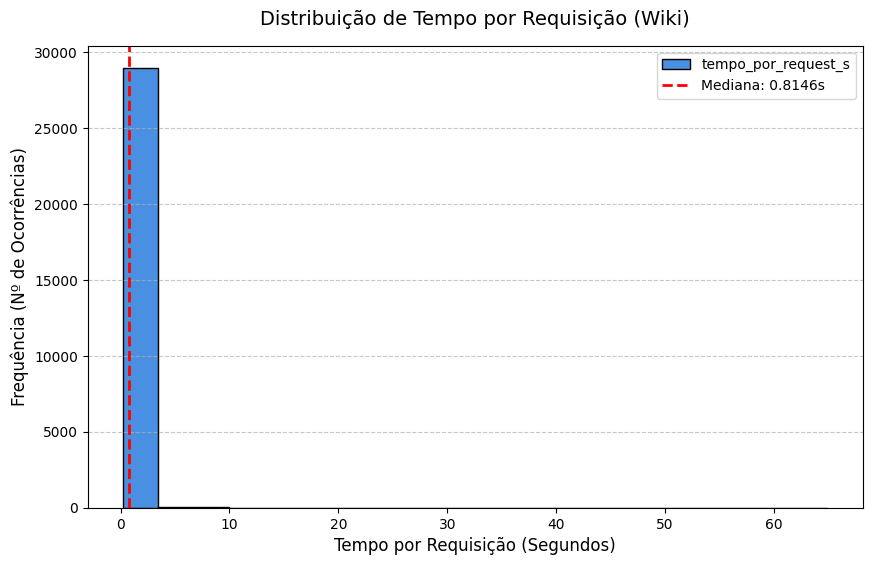

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def analisar_csv_wiki():
    arquivo_csv = 'metricas_wiki.csv'
    
    try:
        # Lê o CSV gerado no passo anterior
        df = pd.read_csv(arquivo_csv)
        
        print("--- ANÁLISE ESTATÍSTICA DAS REQUISIÇÕES DA WIKI ---")
        
        # Evitando divisão por zero caso algum programa tenha 0 requests
        df = df[df['num_requests'] > 0].copy()
        
        # Calcula o tempo que CADA requisição leva em média por programa
        df['tempo_por_request_s'] = df['wiki_search_time_s'] / df['num_requests']
        
        # Seleciona as colunas numéricas que temos no CSV + a nova coluna calculada
        colunas_analise = ['wiki_search_time_s', 'num_requests', 'request_per_s', 'tempo_por_request_s']
        
        # O método describe() já calcula count, mean, std, min, 25%, 50% (mediana), 75% e max
        resumo = df[colunas_analise].describe()
        
        # Exibe a tabela completa arredondada para 4 casas decimais
        print(resumo.round(4))

        print("\nGerando o gráfico de distribuição de tempo por requisição...")
        
        # --- CÓDIGO PARA PLOTAR A DISTRIBUIÇÃO ---
        plt.figure(figsize=(10, 6))
        
        # Criando um histograma com o tempo por request
        # bins=20 divide os dados em 20 colunas para facilitar a visualização
        df['tempo_por_request_s'].plot(kind='hist', bins=20, color='#4A90E2', edgecolor='black')
        
        plt.title('Distribuição de Tempo por Requisição (Wiki)', fontsize=14, pad=15)
        plt.xlabel('Tempo por Requisição (Segundos)', fontsize=12)
        plt.ylabel('Frequência (Nº de Ocorrências)', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Destacando a mediana no gráfico com uma linha vermelha
        mediana_tempo = df['tempo_por_request_s'].median()
        plt.axvline(mediana_tempo, color='red', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_tempo:.4f}s')
        plt.legend()
        
        # Exibe a interface gráfica
        plt.show()

    except FileNotFoundError:
        print(f"Erro: O arquivo '{arquivo_csv}' não foi encontrado. Certifique-se de que ele está na mesma pasta.")
    except Exception as e:
        print(f"Erro inesperado: {e}")

if __name__ == '__main__':
    analisar_csv_wiki()